In [1]:
import os
import numpy as np 
import pandas as pd
from numpy import sqrt, floor
from scipy.constants import c, m_e, e as q_e, m_p
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D 
from openpmd_viewer import OpenPMDTimeSeries
import imageio.v2 as imageio
from IPython.display import Video

## Beam parameters

In [2]:
mass = m_p
energy = 6.7e6 * q_e
velocity = sqrt(2 * energy / mass) 
beta_x = 0.737881
beta_y = 0.737881
beta_t = 0.25
alpha_x = +2.4685083
alpha_y = -2.4685083
alpha_t = 0.
gamma_x = (1+alpha_x**2)/beta_x 
gamma_y = (1+alpha_y**2)/beta_y 
gamma_t = (1+alpha_t**2)/beta_t 
emitt_x = 1.0e-6
emitt_y = 1.0e-6
emitt_t = 1.0e-6
sigma_x = sqrt(emitt_x * beta_x)
sigma_y = sqrt(emitt_y * beta_y)
sigma_z = sqrt(emitt_t * beta_t)

## Lattice parameters

In [3]:
L_drift1 = 7.44e-2
L_drift2 = 14.88e-2 
L_drift3 = 7.44e-2 
L_quad = 6.10e-2

## Simulation box

In [4]:
Lx = 20*sigma_x
Ly = 20*sigma_y
zmin = -20*sigma_z 
zmax = 0.5*zmin 
Lz = zmax - zmin 

## Beam size and emittance in time

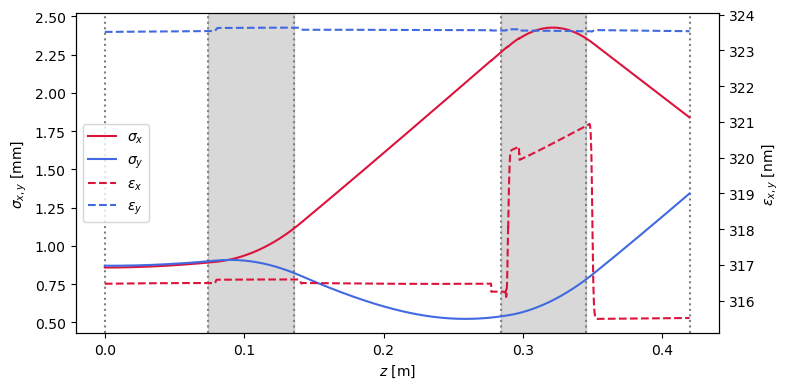

In [5]:
# Load the BeamRelevant diagnostic
df = pd.read_csv('./diags/reducedfiles/beam_stats.txt', sep=" ", header=0)
# Extract desired columns
times = df[[col for col in df.columns if f']time' in col]].to_numpy()
sigma_x = df[[col for col in df.columns if f']x_rms' in col]].to_numpy()
sigma_y = df[[col for col in df.columns if f']y_rms' in col]].to_numpy()
emitt_x = df[[col for col in df.columns if f']emittance_x' in col]].to_numpy()
emitt_y = df[[col for col in df.columns if f']emittance_y' in col]].to_numpy()

# Plot
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(8, 4))

# Lattice elements
ax.axvline(x=0,color="gray", ls="dotted")
ax.axvline(x=L_drift1,color="gray", ls="dotted")
im_qu = ax.axvspan(L_drift1, L_drift1+L_quad, color='gray', alpha=0.3, label='Quad')
ax.axvline(x=L_drift1+L_quad,color="gray", ls="dotted")
ax.axvline(x=L_drift1+L_quad+L_drift2,color="gray", ls="dotted")
ax.axvspan(L_drift1+L_quad+L_drift2, L_drift1+L_quad+L_drift2+L_quad, color='gray', alpha=0.3, label='Quad')
ax.axvline(x=L_drift1+L_quad+L_drift2+L_quad,color="gray", ls="dotted")
ax.axvline(x=L_drift1+L_quad+L_drift2+L_quad+L_drift3,color="gray", ls="dotted")
# Beam size
im_sx = ax.plot(times*velocity, sigma_x*1e3, color="crimson", label=r"$\sigma_x$")
im_sy = ax.plot(times*velocity, sigma_y*1e3, color="royalblue", label=r"$\sigma_y$")
# Beam emittance
bx = ax.twinx()
im_ex = bx.plot(times*velocity, emitt_x*1e9, color="crimson", ls="dashed", label=r"$\epsilon_x$")
im_ey = bx.plot(times*velocity, emitt_y*1e9, color="royalblue", ls="dashed", label=r"$\epsilon_y$")

ax.legend(handles=im_sx + im_sy + im_ex + im_ey, loc="center left")

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$\sigma_{x,y}$ [mm]")
bx.set_ylabel(r"$\epsilon_{x,y}$ [nm]")
fig.tight_layout()
plt.show()

## Phase space

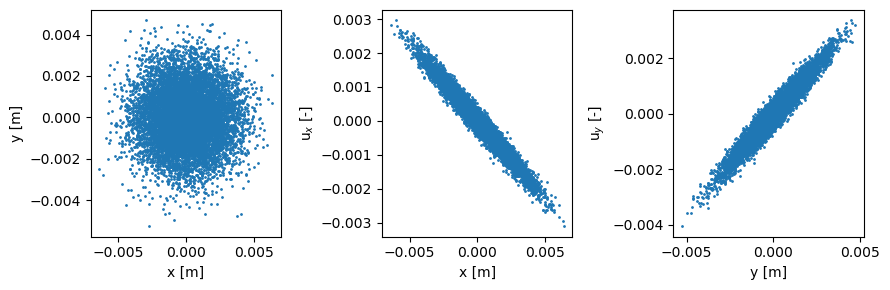

In [6]:
series = OpenPMDTimeSeries(f"diags/particles_in")
iterations = series.iterations

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(9,3))
x,y,ux,uy = series.get_particle(['x','y','ux','uy'], iteration=iterations[-1], species='beam')
ax[0].scatter(x,  y, s=1)
ax[0].set(xlabel="x [m]", ylabel="y [m]")
ax[1].scatter(x, ux, s=1)
ax[1].set(xlabel="x [m]", ylabel=r"u$_x$ [-]")
ax[2].scatter(y, uy, s=1)
ax[2].set(xlabel="y [m]", ylabel=r"u$_y$ [-]")

fig.tight_layout()
plt.show()

## Beam particles in space

In [7]:
series = OpenPMDTimeSeries(f"diags/particles_in")
iterations = series.iterations
dt = series.t[-1]/series.iterations[-1]

video_filename = "particle_evolution.mp4"

with imageio.get_writer(video_filename, fps=30, codec='libx264') as writer:
    for i in iterations:

        fig, ax = plt.subplots(figsize=(6, 4), subplot_kw={'projection': '3d'})

        z, x, y, uz = series.get_particle(['z', 'x', 'y', 'uz'], iteration=i, species='beam')
        zavg = np.average(z) 
        ax.scatter(z, x, y, c=uz, s=1, cmap="viridis")
        
        ax.set_xlabel("z [m]")
        ax.set_ylabel("x [m]")
        ax.set_zlabel("y [m]")
        
        ax.set_xlim(zavg-0.5*Lz, zavg+0.5*Lz)
        ax.set_ylim(-0.5*Lx, 0.5*Lx)
        ax.set_zlim(-0.5*Ly, 0.5*Ly)

        ax.set_aspect("auto")
        ax.set_title(f"Iteration {i}, Time = {i*dt:.2e} s")
        ax.grid(True)
        fig.tight_layout()

        fig.canvas.draw()
        image = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
        writer.append_data(image)
        plt.close(fig)

Video(video_filename, embed=False)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
